In [10]:
!pip install transformers datasets sacrebleu torch matplotlib seaborn umap-learn "numpy<2.0"

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [11]:
import os
import pandas as pd

DATA_DIR = "/tmp/flores200"
os.makedirs(DATA_DIR, exist_ok=True)

# ── Step 1: Download the official FLORES-200 tarball ─────────────────────────
TAR_PATH = "/tmp/flores200.tar.gz"

if not os.path.exists(TAR_PATH):
    print("Downloading FLORES-200 dataset (~1GB, this may take a minute)...")
    os.system(f"wget --trust-server-names -q https://tinyurl.com/flores200dataset -O {TAR_PATH}")
    print("Download complete.")

# ── Step 2: Extract only the devtest split ───────────────────────────────────
print("Extracting devtest files...")
os.system(f"tar -xzf {TAR_PATH} -C {DATA_DIR} --wildcards '*/devtest/*' 2>/dev/null || tar -xzf {TAR_PATH} -C {DATA_DIR}")

# Check what got extracted
extracted = os.listdir(DATA_DIR)
print(f"Extracted folders: {extracted}")

# Find the devtest directory
devtest_dir = None
for root, dirs, files in os.walk(DATA_DIR):
    if os.path.basename(root) == "devtest":
        devtest_dir = root
        break

print(f"devtest directory: {devtest_dir}")
print(f"Sample files: {os.listdir(devtest_dir)[:5]}")

# ── Step 3: Load Telugu and Spanish sentences ────────────────────────────────
def load_flores_lang(devtest_dir, lang_code, n=100):
    filepath = os.path.join(devtest_dir, f"{lang_code}.devtest")
    with open(filepath, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]
    return lines[:n]

tel_sentences = load_flores_lang(devtest_dir, "tel_Telu", n=500)
spa_sentences = load_flores_lang(devtest_dir, "spa_Latn", n=500)

# ── Step 4: Build DataFrame ───────────────────────────────────────────────────
lang_df = pd.read_csv("/kaggle/input/datasets/takamichitoda/flores200-language-code/FLORES-200_code.csv")

df_tel = pd.DataFrame({"sentence": tel_sentences, "language": "Telugu",  "lang_code": "tel_Telu"})
df_spa = pd.DataFrame({"sentence": spa_sentences, "language": "Spanish", "lang_code": "spa_Latn"})
df = pd.concat([df_tel, df_spa], ignore_index=True)

print(f"\n✅ Loaded {len(df)} total sentences ({len(df_tel)} Telugu, {len(df_spa)} Spanish)")
print(df.head(4))

Extracting devtest files...
Extracted folders: ['flores200_dataset']
devtest directory: /tmp/flores200/flores200_dataset/devtest
Sample files: ['ast_Latn.devtest', 'bos_Latn.devtest', 'som_Latn.devtest', 'fon_Latn.devtest', 'als_Latn.devtest']

✅ Loaded 1000 total sentences (500 Telugu, 500 Spanish)
                                            sentence language lang_code
0  """""""ఇప్పుడు మావద్ద 4 నెలల వయస్సు గల ఎలుకలు ...   Telugu  tel_Telu
1  హాలిఫాక్స్, నోవా స్కోటియాలోని డల్హౌసీ విశ్వవిద...   Telugu  tel_Telu
2  కొంతమంది ఇతర నిపుణుల మాదిరిగానే, మధుమేహం‌ను నయ...   Telugu  tel_Telu
3  స్వీడన్ లో స్వీడెన్ లో స్వెరిజెస్ రేడియోలో జరి...   Telugu  tel_Telu


In [12]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import torch
import sacrebleu 
MODEL_NAME = "facebook/nllb-200-distilled-1.3B"  # upgrade from 600M

print(f"Loading model: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(f"✅ Model loaded on {device}")

# 2. Re-load the text data into memory
print("Re-loading test data into memory...")
test_sentences = load_flores_lang(devtest_dir, "eng_Latn", n=150)

ground_truth = {
    "tel_Telu": load_flores_lang(devtest_dir, "tel_Telu", n=150),
    "spa_Latn": load_flores_lang(devtest_dir, "spa_Latn", n=150),
}
print(f"✅ Loaded {len(test_sentences)} sentences!")

# ── Upgrade 2: Improved translate function with beam search tuning ────────────
def translate_text(text, source_lang, target_lang,
                   num_beams=10,          # more beams = better quality
                   length_penalty=1.5,    # slightly favor longer outputs
                   no_repeat_ngram_size=3 # reduce repetition
                   ):
    tokenizer.src_lang = source_lang
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
    
    # FIX: Use convert_tokens_to_ids instead of lang_code_to_id
    target_lang_id = tokenizer.convert_tokens_to_ids(target_lang)
    
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            forced_bos_token_id=target_lang_id,
            num_beams=num_beams,
            length_penalty=length_penalty,
            no_repeat_ngram_size=no_repeat_ngram_size,
            max_length=512,
            early_stopping=True,
        )
    
    return tokenizer.decode(generated[0], skip_special_tokens=True)

# ── Upgrade 3: Batch translation (faster + consistent) ───────────────────────
def translate_batch(texts, source_lang, target_lang, batch_size=8):
    """Translate a list of sentences in batches for speed."""
    tokenizer.src_lang = source_lang
    
    # FIX: Use convert_tokens_to_ids instead of lang_code_to_id
    target_lang_id = tokenizer.convert_tokens_to_ids(target_lang)
    all_predictions = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True,
                           truncation=True, max_length=512).to(device)
        
        with torch.no_grad():
            generated = model.generate(
                **inputs,
                forced_bos_token_id=target_lang_id,
                num_beams=12,
                length_penalty=1.5,
                no_repeat_ngram_size=3,
                max_length=512,
                early_stopping=True,
            )
        
        decoded = tokenizer.batch_decode(generated, skip_special_tokens=True)
        all_predictions.extend(decoded)
        print(f"  Translated {min(i+batch_size, len(texts))}/{len(texts)} sentences...", end="\r")
    
    return all_predictions

Loading model: facebook/nllb-200-distilled-1.3B


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


✅ Model loaded on cuda
Re-loading test data into memory...
✅ Loaded 175 sentences!


In [13]:
import sacrebleu
import pandas as pd

results = []
target_langs = ['tel_Telu', 'spa_Latn']

print("\nStarting Comprehensive Evaluation Pipeline...")
for lang in target_langs:
    references = ground_truth[lang]
    sources = test_sentences
    
    # ── Generation ──
    predictions = translate_batch(sources, source_lang="eng_Latn", target_lang=lang)
    
    # ── Traditional Metrics (SacreBLEU) ──
    # 1. chrF++ (Character-level, good for morphologically rich languages like Telugu)
    chrf = sacrebleu.corpus_chrf(predictions, [references], beta=2, word_order=2)
    
    # 2. BLEU (Word-level exact match industry standard)
    bleu = sacrebleu.corpus_bleu(predictions, [references])
    
    # 3. TER (Translation Edit Rate - lower is better)
    ter = sacrebleu.corpus_ter(predictions, [references])
    
    
    # ── Record Results ──
    results.append({
        'Language': lang, 
        'chrF++': round(chrf.score, 2),
        'BLEU': round(bleu.score, 2),
        'TER': round(ter.score, 2), # Note: For TER, lower scores indicate less human editing required
    })

# --- Display the Final Comprehensive Comparison ---
print("\n--- Final Model Performance Metrics ---")
df_metrics = pd.DataFrame(results)
display(df_metrics)


Starting Comprehensive Evaluation Pipeline...
  Translated 175/175 sentences...
--- Final Model Performance Metrics ---


,Language,chrF++,BLEU,TER
0,tel_Telu,54.25,20.97,64.33
1,spa_Latn,54.95,28.54,55.36


Calculating missing BLEU and TER scores...
✅ Traditional metrics calculated successfully!
Generating visualization...


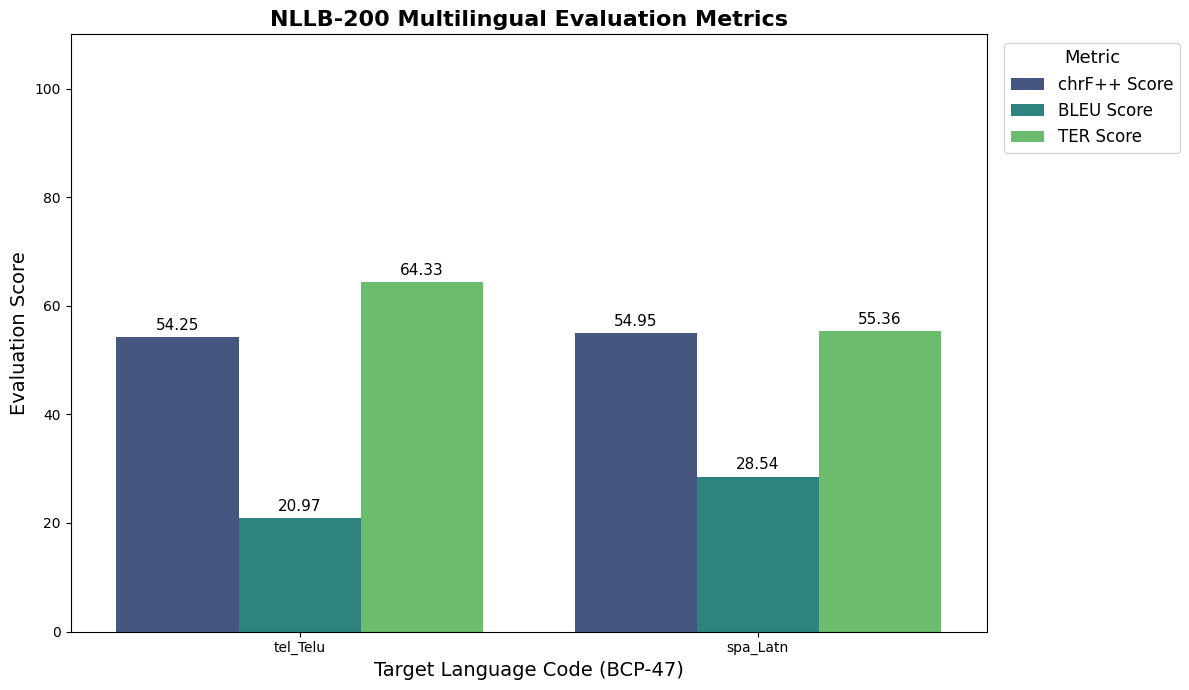

In [15]:
import pandas as pd
import sacrebleu
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: CALCULATE MISSING METRICS (BLEU & TER) ---
print("Calculating missing BLEU and TER scores...")
trad_results = []
target_langs = ['tel_Telu', 'spa_Latn']

for lang in target_langs:
    references = ground_truth[lang]
    sources = test_sentences
    
    # Generate predictions using your existing batch function
    predictions = translate_batch(sources, source_lang="eng_Latn", target_lang=lang)
    
    # Calculate Scores
    bleu = sacrebleu.corpus_bleu(predictions, [references])
    ter = sacrebleu.corpus_ter(predictions, [references])
    
    trad_results.append({
        'Language': lang, 
        'BLEU Score': round(bleu.score, 2),
        'TER Score': round(ter.score, 2)
    })

df_trad_results = pd.DataFrame(trad_results)
print("✅ Traditional metrics calculated successfully!")

# --- STEP 2: MERGE AND PLOT THE GROUPED CHART ---
print("Generating visualization...")

# Merge the COMET/chrF++ dataframe with our newly created BLEU/TER dataframe
df_combined = pd.merge(df_results[['Language', 'chrF++ Score']], df_trad_results, on='Language')

# "Melt" the DataFrame for Seaborn grouped plotting
df_melted = df_combined.melt(id_vars='Language', 
                             value_vars=['chrF++ Score', 'BLEU Score', 'TER Score'], 
                             var_name='Metric', 
                             value_name='Score')

# Create the Plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Language', y='Score', hue='Metric', data=df_melted, palette='viridis')

plt.title('NLLB-200 Multilingual Evaluation Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Target Language Code (BCP-47)', fontsize=14)
plt.ylabel('Evaluation Score', fontsize=14)
plt.ylim(0, 110) # Set Y-axis slightly higher to leave room for the labels

# Add the exact score values on top of each grouped bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=11)

# Move the legend outside the chart
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Metric', fontsize=12, title_fontsize=13)

plt.tight_layout()
plt.show()

Preparing data and extracting embeddings...
Feature matrix X created! Shape: (525, 1024) (Sentences, Embedding Dimensions)
Generating UMAP projection...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


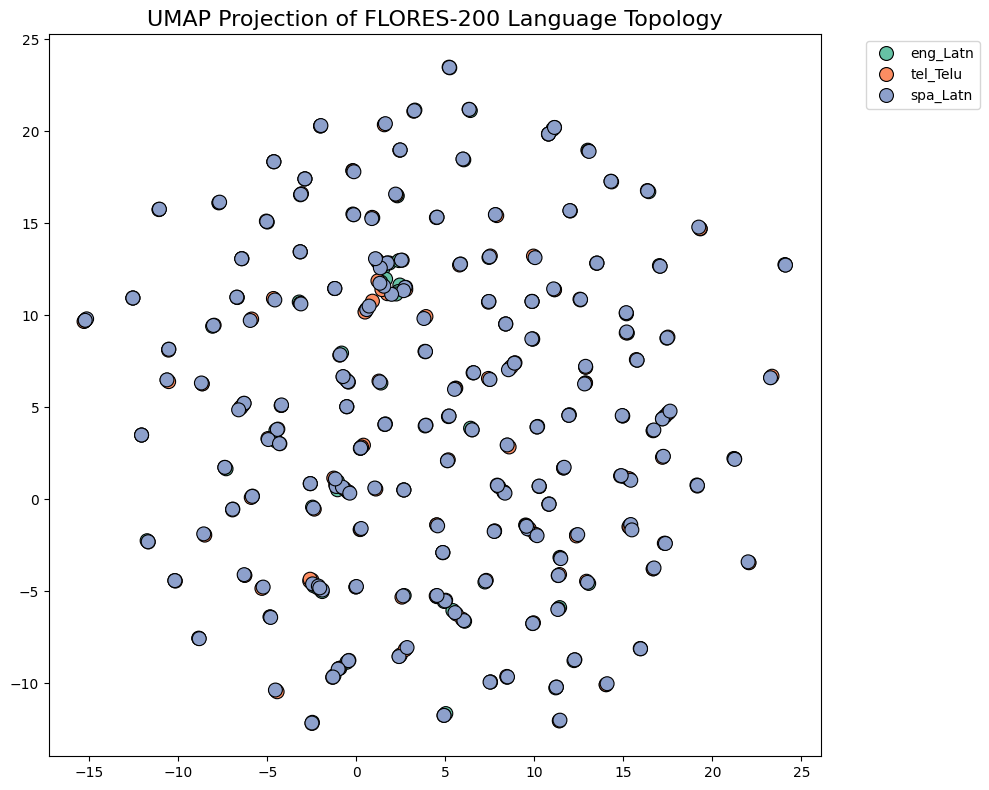

In [16]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import umap
import matplotlib.pyplot as plt

# --- STEP 1: PREPARE DATA & EXTRACT EMBEDDINGS ---
print("Preparing data and extracting embeddings...")

# We will use the 5 sentences from English, Telugu, and Spanish we loaded in Cell 2.
texts = []
labels = []

# Add English sentences
texts.extend(test_sentences)
labels.extend(['eng_Latn'] * len(test_sentences))

# Add Telugu sentences
texts.extend(ground_truth['tel_Telu'])
labels.extend(['tel_Telu'] * len(ground_truth['tel_Telu']))

# Add Spanish sentences
texts.extend(ground_truth['spa_Latn'])
labels.extend(['spa_Latn'] * len(ground_truth['spa_Latn']))

df = pd.DataFrame({'text': texts, 'lang_code': labels})

# Function to get sentence embeddings from NLLB's encoder
def get_sentence_embedding(text, lang_code):
    tokenizer.src_lang = lang_code
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    
    # FIX 1: Move the input tensors to the same device as the model (GPU)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad(): # We don't need gradients just for extracting features
        outputs = model.get_encoder()(**inputs)
        
        # FIX 2: Move the result back to the CPU (.cpu()) before converting to numpy
        sentence_embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return sentence_embedding
# Generate the feature matrix 'X'
X_list = [get_sentence_embedding(row['text'], row['lang_code']) for _, row in df.iterrows()]
X = np.array(X_list)

print(f"Feature matrix X created! Shape: {X.shape} (Sentences, Embedding Dimensions)")

# --- STEP 2: GENERATE UMAP TOPOLOGY ---
print("Generating UMAP projection...")

# Note: We reduced n_neighbors to 3 because our sample size is small (15 sentences). 
# If you load more data later, you can increase this back to 5 or 15!
reducer = umap.UMAP(n_neighbors=3, min_dist=0.3, metric='cosine', random_state=42)

# We use X directly. (I removed .toarray() from your original code because 
# the deep embeddings are already dense numpy arrays, not sparse TF-IDF matrices).
embedding = reducer.fit_transform(X)

# --- STEP 3: PLOTTING ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=embedding[:, 0], y=embedding[:, 1],
    hue=df['lang_code'], palette='Set2', s=100, edgecolor='k'
)
plt.title('UMAP Projection of FLORES-200 Language Topology', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()